In [1]:
import pandas as pd
import numpy as np
from datetime import time

In [2]:
df = pd.read_csv("/Users/ruhan/Downloads/btcusd_1-min_data (1).csv")

In [3]:
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


In [4]:
df.shape

(7623380, 6)

In [5]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")

df.tail()

,Timestamp,Open,High,Low,Close,Volume
7623375,2026-06-30 00:16:00,60129.68,60138.72,60123.78,60138.61,0.087010
7623376,2026-06-30 00:17:00,60138.61,60138.61,60125.28,60128.73,0.019076
7623377,2026-06-30 00:18:00,60128.73,60128.73,60107.42,60107.42,0.027054
7623378,2026-06-30 00:19:00,60107.43,60107.43,60064.57,60070.57,5.223221
7623379,2026-06-30 00:20:00,60069.13,60078.45,60035.27,60045.97,1.068140


In [6]:
# print("Start ", df["Timestamp"].min())
# print("End   ", df["Timestamp"].max())

In [7]:
df = df[(df["Timestamp"] >= "2020-01-01") & (df["Timestamp"] < "2026-01-01")].copy()

In [8]:
print("Start ", df["Timestamp"].min())
print("End   ", df["Timestamp"].max())

Start  2020-01-01 00:00:00
End    2025-12-31 23:59:00


In [9]:
# df.isnull().sum()

In [10]:
# df.info()

In [11]:
# duplicates = df["Timestamp"].duplicated().sum()

# print("Duplicate timestamps:", duplicates)

In [12]:
df["Date"] = df["Timestamp"].dt.date

In [13]:
df["Time"] = df["Timestamp"].dt.time

In [14]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date,Time
4207679,2020-01-01 00:00:00,7160.69,7160.69,7159.64,7159.64,5.501691,2020-01-01,00:00:00
4207680,2020-01-01 00:01:00,7161.51,7161.51,7155.09,7161.20,3.776924,2020-01-01,00:01:00
4207681,2020-01-01 00:02:00,7158.82,7158.82,7158.82,7158.82,0.029278,2020-01-01,00:02:00
4207682,2020-01-01 00:03:00,7158.82,7158.82,7156.90,7156.90,0.065819,2020-01-01,00:03:00
4207683,2020-01-01 00:04:00,7158.50,7158.50,7154.97,7157.20,0.971387,2020-01-01,00:04:00


In [15]:

ny_open_time = time(13, 0)
ny_open = df[df["Time"] == ny_open_time][["Date", "Open"]]
ny_open = ny_open.rename(columns={"Open": "NY_Open"})

In [16]:
ny_close_time = time(20, 0)
ny_close = df[df["Time"] == ny_close_time][["Date", "Close"]]
ny_close = ny_close.rename(columns={"Close": "NY_Close"})

In [17]:
daily = pd.merge(
    ny_open,
    ny_close,
    on="Date",
    how="inner"
)

In [18]:
daily["Target"] = ( daily["NY_Close"] > daily["NY_Open"]).astype(int)

In [19]:
daily

,Date,NY_Open,NY_Close,Target
0,2020-01-01,7202.73,7206.53,1
1,2020-01-02,7139.47,6967.00,0
2,2020-01-03,7315.00,7337.15,1
3,2020-01-04,7298.12,7316.65,1
4,2020-01-05,7457.64,7428.78,0
...,...,...,...,...
2187,2025-12-27,87423.00,87513.00,1
2188,2025-12-28,87784.00,87471.00,0
2189,2025-12-29,87258.00,87207.00,0
2190,2025-12-30,87901.00,88076.00,1


In [20]:
daily["Target"].value_counts()

Target
1    1127
0    1065
Name: count, dtype: int64

In [21]:
daily_ohlc = (
    df.groupby("Date")
      .agg(
          Day_Open=("Open", "first"),
          Day_High=("High", "max"),
          Day_Low=("Low", "min"),
          Day_Close=("Close", "last")
      )
      .reset_index()
)

In [22]:
daily_ohlc["Prev_Open"] = daily_ohlc["Day_Open"].shift(1)
daily_ohlc["Prev_High"] = daily_ohlc["Day_High"].shift(1)
daily_ohlc["Prev_Low"] = daily_ohlc["Day_Low"].shift(1)
daily_ohlc["Prev_Close"] = daily_ohlc["Day_Close"].shift(1)


In [23]:
# Previous Day Return (%)
daily_ohlc["Prev_Return"] = (
    (daily_ohlc["Prev_Close"] - daily_ohlc["Prev_Open"])
    / daily_ohlc["Prev_Open"]
) * 100

# Previous Day Range (%)
daily_ohlc["Prev_Range_Pct"] = (
    (daily_ohlc["Prev_High"] - daily_ohlc["Prev_Low"])
    / daily_ohlc["Prev_Open"]
) * 100

# Previous Day Direction
daily_ohlc["Prev_Direction"] = (
    daily_ohlc["Prev_Close"] >
    daily_ohlc["Prev_Open"]
).astype(int)

In [24]:
daily_ohlc.head()

,Date,Day_Open,Day_High,Day_Low,Day_Close,Prev_Open,Prev_High,Prev_Low,Prev_Close,Prev_Return,Prev_Range_Pct,Prev_Direction
0,2020-01-01,7160.69,7237.35,7150.00,7178.68,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2020-01-02,7174.70,7184.94,6900.00,6950.56,7160.69,7237.35,7150.00,7178.68,0.251233,1.219855,1
2,2020-01-03,6945.70,7402.31,6853.53,7338.91,7174.70,7184.94,6900.00,6950.56,-3.124033,3.971455,0
3,2020-01-04,7332.58,7396.10,7256.03,7344.48,6945.70,7402.31,6853.53,7338.91,5.661200,7.901003,1
4,2020-01-05,7356.05,7495.00,7310.00,7356.70,7332.58,7396.10,7256.03,7344.48,0.162289,1.910242,1


In [25]:
prev_day_features = daily_ohlc[
[
    "Date",
    "Prev_Return",
    "Prev_Range_Pct",
    "Prev_Direction"
]
]

In [26]:
# type(prev_day_features)

In [27]:
dataset = daily.merge(
    prev_day_features,
    on="Date",
    how="left"
)

In [28]:
dataset.head()

,Date,NY_Open,NY_Close,Target,Prev_Return,Prev_Range_Pct,Prev_Direction
0,2020-01-01,7202.73,7206.53,1,NaN,NaN,0
1,2020-01-02,7139.47,6967.00,0,0.251233,1.219855,1
2,2020-01-03,7315.00,7337.15,1,-3.124033,3.971455,0
3,2020-01-04,7298.12,7316.65,1,5.661200,7.901003,1
4,2020-01-05,7457.64,7428.78,0,0.162289,1.910242,1


In [29]:


asian = df[
    (df["Time"] >= time(0, 0)) &
    (df["Time"] < time(8, 0))
].copy()

london = df[
    (df["Time"] >= time(8, 0)) &
    (df["Time"] < time(13, 30))
].copy()

In [30]:
asian_features = (
    asian.groupby("Date")
    .agg(
        Asian_Open=("Open", "first"),
        Asian_High=("High", "max"),
        Asian_Low=("Low", "min"),
        Asian_Close=("Close", "last"),
    )
    .reset_index()
)

In [31]:
# Asian Return (%)
asian_features["Asian_Return"] = (
    (asian_features["Asian_Close"] - asian_features["Asian_Open"])
    / asian_features["Asian_Open"]
) * 100

# Asian Range (%)
asian_features["Asian_Range_Pct"] = (
    (asian_features["Asian_High"] - asian_features["Asian_Low"])
    / asian_features["Asian_Open"]
) * 100

asian_features["Asian_Direction"] = (
    asian_features["Asian_Close"] >
    asian_features["Asian_Open"]
).astype(int)


asian_features = asian_features[
[
    "Date",
    "Asian_Return",
    "Asian_Range_Pct",
    "Asian_Direction"
]
]

In [32]:
london_features = (
    london.groupby("Date")
    .agg(
        London_Open=("Open", "first"),
        London_High=("High", "max"),
        London_Low=("Low", "min"),
        London_Close=("Close", "last"),
    )
    .reset_index()
)

In [33]:
# London Return (%)
london_features["London_Return"] = (
    (london_features["London_Close"] - london_features["London_Open"])
    / london_features["London_Open"]
) * 100

# London Range (%)
london_features["London_Range_Pct"] = (
    (london_features["London_High"] - london_features["London_Low"])
    / london_features["London_Open"]
) * 100

london_features["London_Direction"] = (
    london_features["London_Close"] >
    london_features["London_Open"]
).astype(int)


london_features = london_features[
[
    "Date",
    "London_Return",
    "London_Range_Pct",
    "London_Direction"
]
]

In [34]:
dataset = dataset.merge(
    asian_features,
    on="Date",
    how="left"
)

dataset = dataset.merge(
    london_features,
    on="Date",
    how="left"
)

In [35]:
dataset.head()

,Date,NY_Open,NY_Close,Target,Prev_Return,Prev_Range_Pct,Prev_Direction,Asian_Return,Asian_Range_Pct,Asian_Direction,London_Return,London_Range_Pct,London_Direction
0,2020-01-01,7202.73,7206.53,1,NaN,NaN,0,0.371473,0.997949,1,0.235198,0.961960,1
1,2020-01-02,7139.47,6967.00,0,0.251233,1.219855,1,-1.381242,1.613447,0,0.706483,1.177001,1
2,2020-01-03,7315.00,7337.15,1,-3.124033,3.971455,0,3.555869,5.938206,1,1.787401,2.506617,1
3,2020-01-04,7298.12,7316.65,1,5.661200,7.901003,1,0.070780,1.166029,1,-0.547805,0.982778,0
4,2020-01-05,7457.64,7428.78,0,0.162289,1.910242,1,1.440719,1.931607,1,-0.641039,1.051080,0


In [36]:
ny_open

,Date,NY_Open
4208459,2020-01-01,7202.73
4209899,2020-01-02,7139.47
4211339,2020-01-03,7315.00
4212779,2020-01-04,7298.12
4214219,2020-01-05,7457.64
...,...,...
7357739,2025-12-27,87423.00
7359179,2025-12-28,87784.00
7360619,2025-12-29,87258.00
7362059,2025-12-30,87901.00


In [37]:
current_price = ny_open.copy()

current_price.rename(
    columns={"NY_Open": "Current_Price"},
    inplace=True
)

In [38]:
dataset = dataset.merge(
    current_price,
    on="Date",
    how="left"
)



In [39]:
levels = daily_ohlc[
    [
        "Date",
        "Prev_High",
        "Prev_Low"
    ]
]

dataset = dataset.merge(
    levels,
    on="Date",
    how="left"
)

In [40]:
dataset["Dist_Prev_High"] = (
    (dataset["Current_Price"] - dataset["Prev_High"])
    / dataset["Prev_High"]
) * 100

In [41]:
dataset["Dist_Prev_Low"] = (
    (dataset["Current_Price"] - dataset["Prev_Low"])
    / dataset["Prev_Low"]
) * 100

In [42]:
dataset.drop(
    columns=[
        "Prev_High",
        "Prev_Low"
    ],
    inplace=True
)
# now no need of it , it was just for the distance from pre day high and low caluclation

In [43]:
dataset = dataset.dropna().reset_index(drop=True)

#as we shift the data by 1 the first column will have NAN value

In [44]:
features = [
    "Prev_Return",
    "Prev_Range_Pct",
    "Prev_Direction",

    "Asian_Return",
    "Asian_Range_Pct",
    "Asian_Direction",

    "London_Return",
    "London_Range_Pct",
    "London_Direction",

    "Dist_Prev_High",
    "Dist_Prev_Low"
]

X = dataset[features]

y = dataset["Target"]


newdata = pd.concat([X,y] , axis = 1 )

newdata.to_csv('final_data_set' , index = False)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
    random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


X_train shape: (1752, 11)
X_test shape: (439, 11)


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [54]:
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)


lr_preds = lr_model.predict(X_test)



print('Accuracy :', accuracy_score(y_test, lr_preds))
print('Precision:', precision_score(y_test, lr_preds))
print('Recall   :', recall_score(y_test, lr_preds))
print('F1 Score :', f1_score(y_test, lr_preds))
print('Classification Report:', classification_report(y_test, lr_preds))



Accuracy : 0.5489749430523918
Precision: 0.5529411764705883
Recall   : 0.6266666666666667
F1 Score : 0.5875
Classification Report:               precision    recall  f1-score   support

           0       0.54      0.47      0.50       214
           1       0.55      0.63      0.59       225

    accuracy                           0.55       439
   macro avg       0.55      0.55      0.55       439
weighted avg       0.55      0.55      0.55       439



=== Decision Tree Evaluation ===
Accuracy : 0.5193621867881549
Precision: 0.5833333333333334
Recall   : 0.21777777777777776
F1 Score : 0.31715210355987056
Classification Report:               precision    recall  f1-score   support

           0       0.50      0.84      0.63       214
           1       0.58      0.22      0.32       225

    accuracy                           0.52       439
   macro avg       0.54      0.53      0.47       439
weighted avg       0.54      0.52      0.47       439



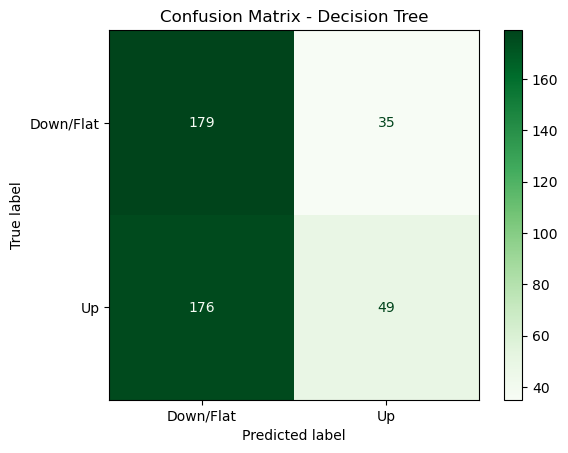

In [49]:
from sklearn.tree import DecisionTreeClassifier

# 2. Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_test)

# Evaluation
print('=== Decision Tree Evaluation ===')
print('Accuracy :', accuracy_score(y_test, dt_preds))
print('Precision:', precision_score(y_test, dt_preds))
print('Recall   :', recall_score(y_test, dt_preds))
print('F1 Score :', f1_score(y_test, dt_preds))
print('Classification Report:', classification_report(y_test, dt_preds))

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Down/Flat', 'Up'])
disp.plot(cmap="Greens")
plt.title('Confusion Matrix - Decision Tree')
plt.show()


In [55]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)


rf_preds = rf_model.predict(X_test)



print('Accuracy :', accuracy_score(y_test, rf_preds))
print('Precision:', precision_score(y_test, rf_preds))
print('Recall   :', recall_score(y_test, rf_preds))
print('F1 Score :', f1_score(y_test, rf_preds))
print('Classification Report:', classification_report(y_test, rf_preds))



Accuracy : 0.5216400911161732
Precision: 0.5306122448979592
Recall   : 0.5777777777777777
F1 Score : 0.5531914893617021
Classification Report:               precision    recall  f1-score   support

           0       0.51      0.46      0.49       214
           1       0.53      0.58      0.55       225

    accuracy                           0.52       439
   macro avg       0.52      0.52      0.52       439
weighted avg       0.52      0.52      0.52       439



In [59]:

models_dict = {
    'Logistic Regression': lr_preds,
    'Decision Tree': dt_preds,
    'Random Forest (Bagging)': rf_preds,
    
}

comparison_list = []
for name, preds in models_dict.items():
    comparison_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds)*100,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds)
    })

summary_df = pd.DataFrame(comparison_list)
summary_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,54.897494,0.552941,0.626667,0.587500
1,Decision Tree,51.936219,0.583333,0.217778,0.317152
2,Random Forest (Bagging),52.164009,0.530612,0.577778,0.553191


In [60]:
import joblib

# Save trained model to file
joblib.dump(lr_model, 'NY_Predict.pkl')
print('Model saved to NY_Predict.pkl successfully!')


Model saved to NY_Predict.pkl successfully!
